In [1]:
from IPython.display import IFrame

IFrame("FEM_implementation.pdf", width=1000, height=800)

## Answer - 7

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import meshzoo
# For Unstructured triangulation
from scipy.spatial import Delaunay 

In [3]:
def create_rectangle_mesh(rectangle_domain, nx_edge, ny_edge, pattern, structure):
    # Rectangle domain
    x0, x1 = rectangle_domain[0]
    y0, y1 = rectangle_domain[1]

    # Define grid
    x = np.linspace(x0, x1, nx_edge + 1)
    y = np.linspace(y0, y1, ny_edge + 1)

    if structure == True:
        # Generate points and triangular cells
        points, cells = meshzoo.rectangle_tri(x, y, variant=pattern)
    else:
        # Random points in 2D between range [0,1] * [0,1]
        points = np.random.rand((nx_edge + 1)*(ny_edge + 1), 2)
        # Scale and shift points to set in given rectangular domain
        points[:, 0] = x0 + (x1 - x0) * points[:, 0]   # set x in [x0,x1]
        points[:, 1] = y0 + (y1 - y0) * points[:, 1]   # set y in [y0,y1]

        # Create Delaunay triangulation (unstructured)
        triangle = Delaunay(points)
        cells = triangle.simplices  
        
    return points, cells

In [4]:
# Inputs for triangulation of rectangular domain
rectangle_domain = np.array([[0, 1],[0, 1]])
nx_edge = 3 
ny_edge = 3

Cell : [0 1 5]
Coordinates : 
 [[0.         0.        ]
 [0.33333333 0.        ]
 [0.33333333 0.33333333]] 

Cell : [4 5 9]
Coordinates : 
 [[0.         0.33333333]
 [0.33333333 0.33333333]
 [0.33333333 0.66666667]] 

Cell : [ 8  9 13]
Coordinates : 
 [[0.         0.66666667]
 [0.33333333 0.66666667]
 [0.33333333 1.        ]] 

Cell : [1 2 6]
Coordinates : 
 [[0.33333333 0.        ]
 [0.66666667 0.        ]
 [0.66666667 0.33333333]] 

Cell : [ 5  6 10]
Coordinates : 
 [[0.33333333 0.33333333]
 [0.66666667 0.33333333]
 [0.66666667 0.66666667]] 

Cell : [ 9 10 14]
Coordinates : 
 [[0.33333333 0.66666667]
 [0.66666667 0.66666667]
 [0.66666667 1.        ]] 

Cell : [2 3 7]
Coordinates : 
 [[0.66666667 0.        ]
 [1.         0.        ]
 [1.         0.33333333]] 

Cell : [ 6  7 11]
Coordinates : 
 [[0.66666667 0.33333333]
 [1.         0.33333333]
 [1.         0.66666667]] 

Cell : [10 11 15]
Coordinates : 
 [[0.66666667 0.66666667]
 [1.         0.66666667]
 [1.         1.        ]] 

Cell

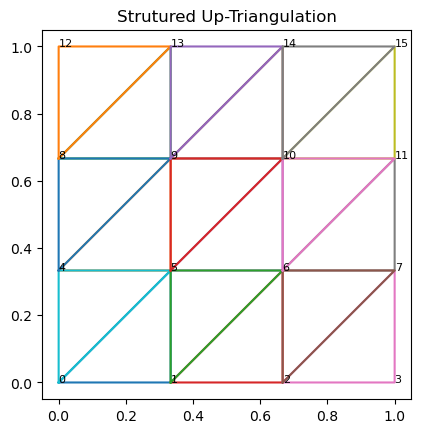

In [5]:
# Generate structured up-triangulation mesh on rectangular domain
points, cells = create_rectangle_mesh(rectangle_domain, nx_edge, ny_edge, pattern="up", structure=True)

for i in range(points.shape[0]):
    print(f'Cell : {cells[i]}')
    print(f'Coordinates : \n {points[cells[i]]} \n')

# Plotting triangulation
fig, ax = plt.subplots()

for triangle in cells:
    polygon = points[triangle]
    polygon = np.vstack([polygon, polygon[0]])  # close triangle
    ax.plot(polygon[:, 0], polygon[:, 1])

# Put labels
for i, (px, py) in enumerate(points):
    ax.text(px, py, str(i), fontsize=8)

ax.set_aspect("equal")
ax.set_title("Strutured Up-Triangulation")
plt.show()

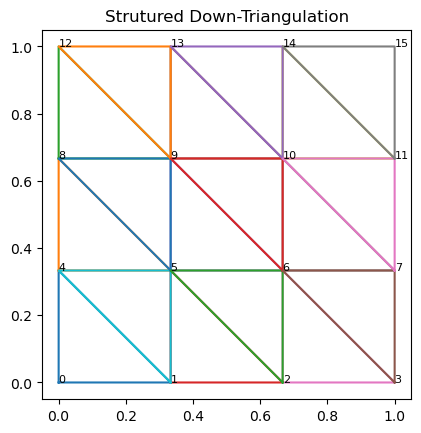

In [6]:
# Generate structured down-triangulation mesh on rectangular domain
points, cells = create_rectangle_mesh(rectangle_domain, nx_edge, ny_edge, pattern="down", structure=True)

# Plotting triangulation
fig, ax = plt.subplots()

for triangle in cells:
    polygon = points[triangle]
    polygon = np.vstack([polygon, polygon[0]])  # close triangle
    ax.plot(polygon[:, 0], polygon[:, 1])

# Put labels
for i, (px, py) in enumerate(points):
    ax.text(px, py, str(i), fontsize=8)

ax.set_aspect("equal")
ax.set_title("Strutured Down-Triangulation")
plt.show()

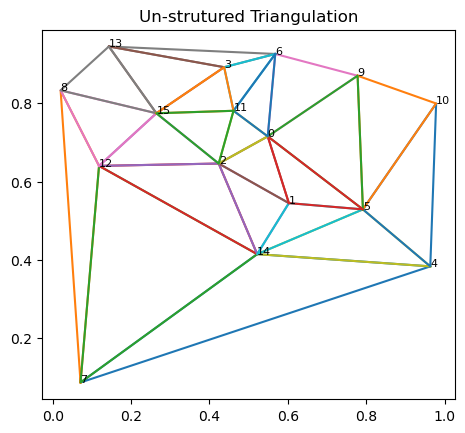

In [7]:
np.random.seed(0)
# Generate Un-structured triangulation mesh on rectangular domain
points, cells = create_rectangle_mesh(rectangle_domain, nx_edge, ny_edge, pattern=0, structure=False)

# Plotting triangulation
fig, ax = plt.subplots()

for triangle in cells:
    polygon = points[triangle]
    polygon = np.vstack([polygon, polygon[0]])  # close triangle
    ax.plot(polygon[:, 0], polygon[:, 1])

# Put labels
for i, (px, py) in enumerate(points):
    ax.text(px, py, str(i), fontsize=8)

ax.set_aspect("equal")
ax.set_title("Un-strutured Triangulation")
plt.show()